In [1]:
from pathlib import Path
import pandas as pd



## Définir les chemins

In [2]:
PROJECT_ROOT = Path.cwd().parent

RAW_MARKET_DIR = PROJECT_ROOT / "data" / "raw" / "market"
RAW_MACRO_DIR = PROJECT_ROOT / "data" / "raw" / "macro"

print("Projet :", PROJECT_ROOT)
print("Market data :", RAW_MARKET_DIR)
print("Macro data :", RAW_MACRO_DIR)

Projet : C:\FORMATION_CONTINUE_AND_TRAINING_SKILLS\420_A62_BB_PROJET_DE_SYNTHESE\ai-trading-system
Market data : C:\FORMATION_CONTINUE_AND_TRAINING_SKILLS\420_A62_BB_PROJET_DE_SYNTHESE\ai-trading-system\data\raw\market
Macro data : C:\FORMATION_CONTINUE_AND_TRAINING_SKILLS\420_A62_BB_PROJET_DE_SYNTHESE\ai-trading-system\data\raw\macro


## Lancer le pipeline de collecte

In [5]:
import sys

sys.path.append(str(PROJECT_ROOT))

from src.pipelines.collect_pipeline import run_data_pipeline

run_data_pipeline()

2026-06-27 00:00:18,590 | INFO | src.pipelines.collect_pipeline | Démarrage du pipeline de données...
2026-06-27 00:00:18,591 | INFO | src.pipelines.collect_pipeline | Étape 1 : Collecte Market Data
2026-06-27 00:00:18,594 | INFO | src.collectors.yahoo_collector | Collecte de gold (GC=F)
2026-06-27 00:00:19,310 | INFO | src.collectors.yahoo_collector | Fichier créé : C:\FORMATION_CONTINUE_AND_TRAINING_SKILLS\420_A62_BB_PROJET_DE_SYNTHESE\ai-trading-system\data\raw\market\gold.csv
2026-06-27 00:00:19,311 | INFO | src.collectors.yahoo_collector | Collecte de silver (SI=F)
2026-06-27 00:00:19,661 | INFO | src.collectors.yahoo_collector | Fichier créé : C:\FORMATION_CONTINUE_AND_TRAINING_SKILLS\420_A62_BB_PROJET_DE_SYNTHESE\ai-trading-system\data\raw\market\silver.csv
2026-06-27 00:00:19,664 | INFO | src.collectors.yahoo_collector | Collecte de nasdaq (NQ=F)
2026-06-27 00:00:19,931 | INFO | src.collectors.yahoo_collector | Fichier créé : C:\FORMATION_CONTINUE_AND_TRAINING_SKILLS\420_A62_BB

## Vérifier les fichiers générés

In [6]:
market_files = list(RAW_MARKET_DIR.glob("*.csv"))
macro_files = list(RAW_MACRO_DIR.glob("*.csv"))

print("Fichiers market :")
for file in market_files:
    print("-", file.name)

print("\nFichiers macro :")
for file in macro_files:
    print("-", file.name)

Fichiers market :
- gold.csv
- nasdaq.csv
- silver.csv
- sp500.csv

Fichiers macro :
- macro_fred.csv


## Charger et afficher les données

In [7]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
MARKET_DIR = PROJECT_ROOT / "data" / "raw" / "market"

assets = {
    "Gold": "gold.csv",
    "Silver": "silver.csv"
}

market_data = {}

for asset, filename in assets.items():

    print("=" * 60)
    print(f"{asset}")
    print("=" * 60)

    df = pd.read_csv(MARKET_DIR / filename)

    market_data[asset] = df

    display(df.head())

    print("\nInformations")
    display(df.info())

    print("\nStatistiques descriptives")
    display(df.describe())

Gold


,Date,Adj Close,Close,High,Low,Open,Volume
0,NaN,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
1,2020-01-02,1524.5,1524.5,1528.699951171875,1518.0,1518.0999755859375,214
2,2020-01-03,1549.199951171875,1549.199951171875,1552.699951171875,1530.0999755859375,1530.0999755859375,107
3,2020-01-06,1566.199951171875,1566.199951171875,1580.0,1560.4000244140625,1580.0,416
4,2020-01-07,1571.800048828125,1571.800048828125,1576.300048828125,1558.300048828125,1558.300048828125,47



Informations
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1632 entries, 0 to 1631
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       1631 non-null   object
 1   Adj Close  1632 non-null   object
 2   Close      1632 non-null   object
 3   High       1632 non-null   object
 4   Low        1632 non-null   object
 5   Open       1632 non-null   object
 6   Volume     1632 non-null   object
dtypes: object(7)
memory usage: 89.4+ KB


None


Statistiques descriptives


...

,Date,Adj Close,Close,High,Low,Open,Volume
0,NaN,SI=F,SI=F,SI=F,SI=F,SI=F,SI=F
1,2020-01-02,17.965999603271484,17.965999603271484,17.989999771118164,17.965999603271484,17.965999603271484,2
2,2020-01-03,18.06800079345703,18.06800079345703,18.110000610351562,17.96500015258789,18.110000610351562,83
3,2020-01-06,18.097000122070312,18.097000122070312,18.104999542236328,18.024999618530273,18.024999618530273,3
4,2020-01-07,18.31599998474121,18.31599998474121,18.344999313354492,18.014999389648438,18.014999389648438,33



Informations
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1632 entries, 0 to 1631
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       1631 non-null   object
 1   Adj Close  1632 non-null   object
 2   Close      1632 non-null   object
 3   High       1632 non-null   object
 4   Low        1632 non-null   object
 5   Open       1632 non-null   object
 6   Volume     1632 non-null   object
dtypes: object(7)
memory usage: 89.4+ KB


None


Statistiques descriptives


,Date,Adj Close,Close,High,Low,Open,Volume
count,1631,1632,1632,1632,1632,1632,1632
unique,1631,1565,1565,1452,1443,1415,538
top,2020-01-02,23.474000930786133,23.474000930786133,25.209999084472656,22.649999618530273,26.200000762939453,0
freq,1,3,3,4,5,4,80


In [8]:
# Graphiques

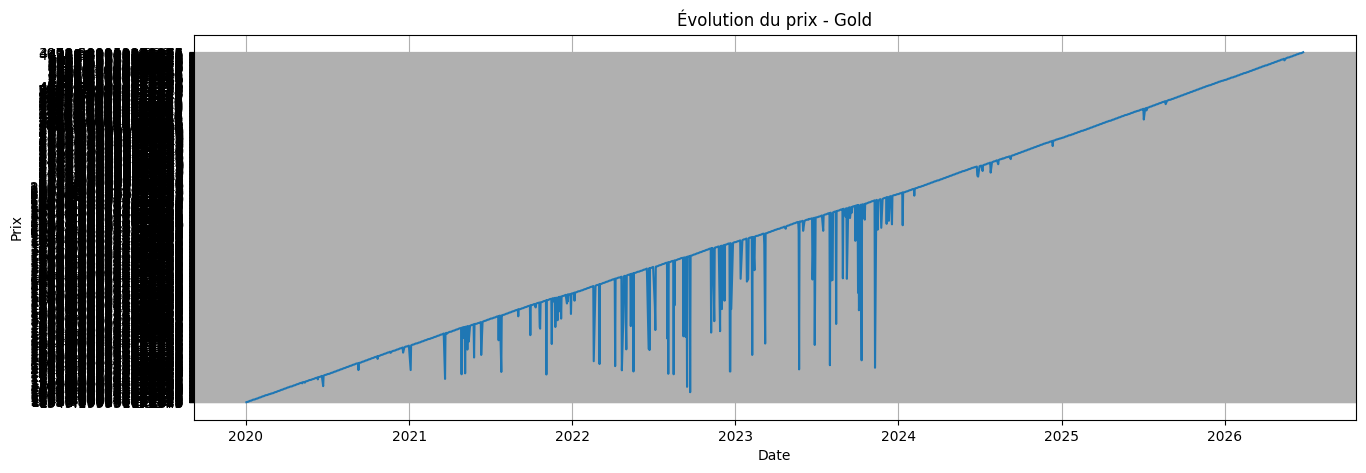

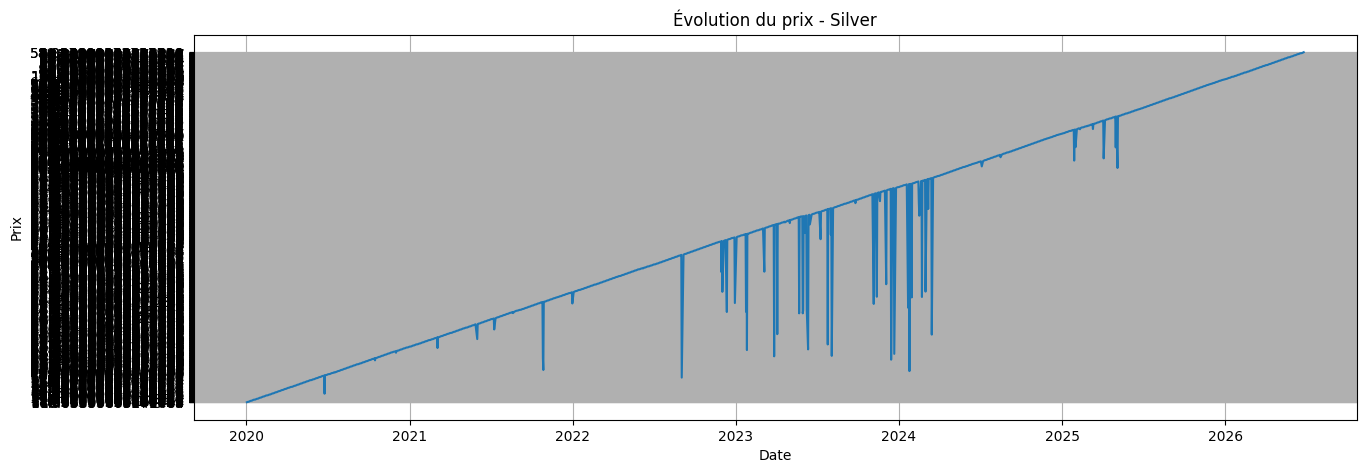

In [9]:
import matplotlib.pyplot as plt

for asset, df in market_data.items():

    plt.figure(figsize=(15,5))

    plt.plot(
        pd.to_datetime(df["Date"]),
        df["Close"]
    )

    plt.title(f"Évolution du prix - {asset}")

    plt.xlabel("Date")

    plt.ylabel("Prix")

    plt.grid(True)

    plt.show()

## Graphiques

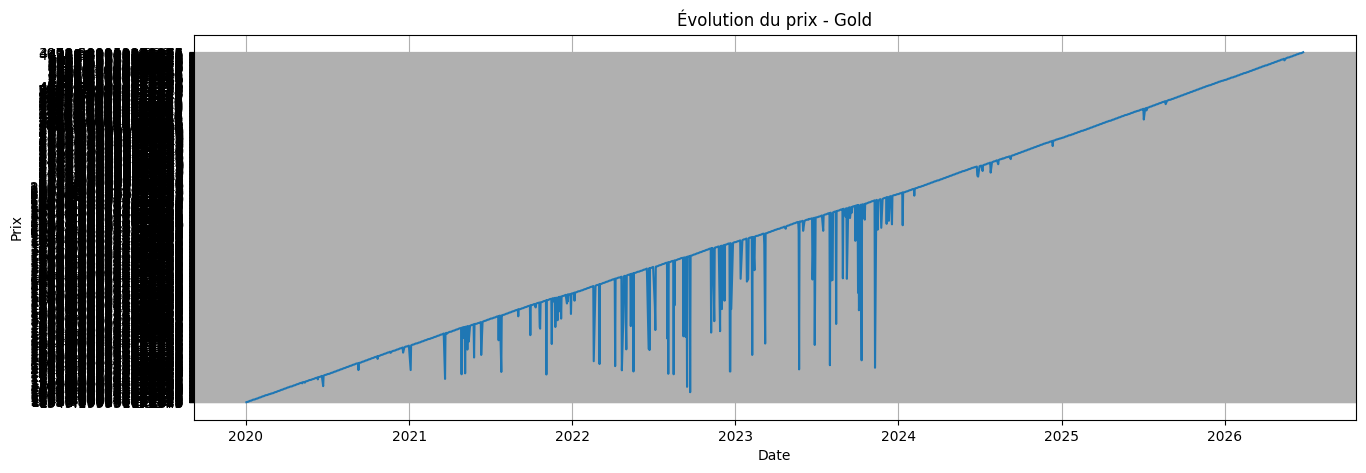

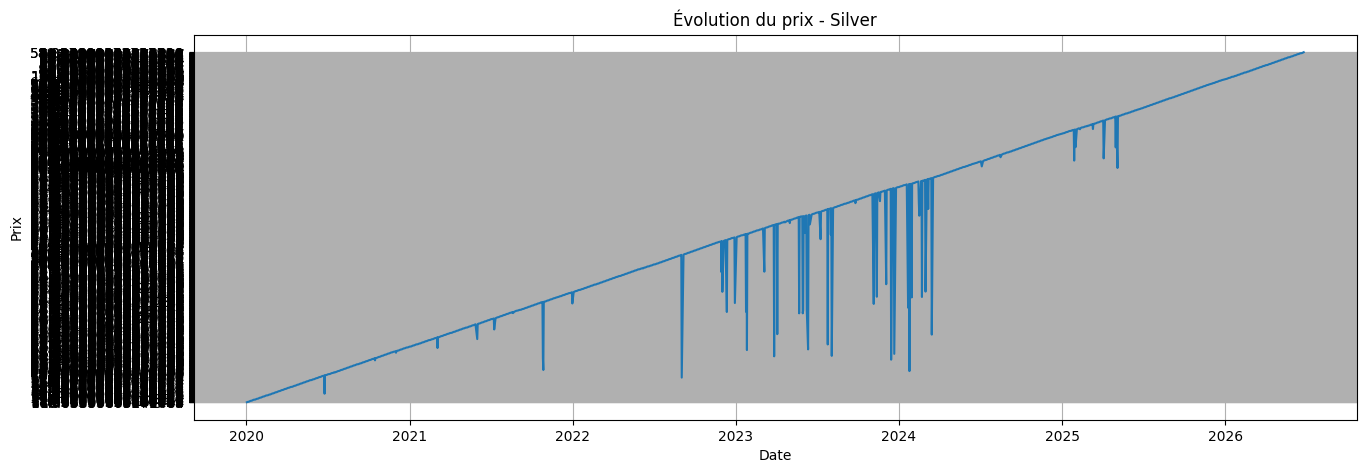

In [10]:
import matplotlib.pyplot as plt

for asset, df in market_data.items():

    plt.figure(figsize=(15,5))

    plt.plot(
        pd.to_datetime(df["Date"]),
        df["Close"]
    )

    plt.title(f"Évolution du prix - {asset}")

    plt.xlabel("Date")

    plt.ylabel("Prix")

    plt.grid(True)

    plt.show()

In [11]:
## Comparaison Gold / Silver

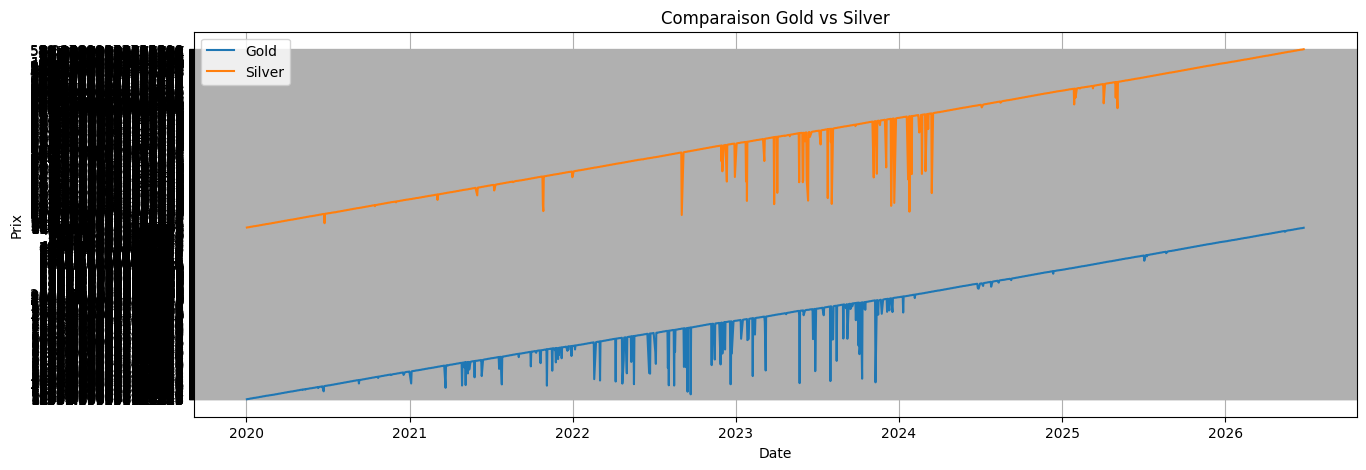

In [12]:
plt.figure(figsize=(15,5))

for asset, df in market_data.items():

    plt.plot(
        pd.to_datetime(df["Date"]),
        df["Close"],
        label=asset
    )

plt.title("Comparaison Gold vs Silver")

plt.xlabel("Date")

plt.ylabel("Prix")

plt.legend()

plt.grid(True)

plt.show()

In [16]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
MARKET_DIR = PROJECT_ROOT / "data" / "raw" / "market"

market_data = {}

for file in MARKET_DIR.glob("*.csv"):

    asset = file.stem.capitalize()

    df = pd.read_csv(file)

    market_data[asset] = df

    print(f"\n{'='*60}")
    print(f"Actif : {asset}")
    print(f"{'='*60}")

    display(df.head())


Actif : Gold


,Date,Adj Close,Close,High,Low,Open,Volume
0,NaN,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
1,2020-01-02,1524.5,1524.5,1528.699951171875,1518.0,1518.0999755859375,214
2,2020-01-03,1549.199951171875,1549.199951171875,1552.699951171875,1530.0999755859375,1530.0999755859375,107
3,2020-01-06,1566.199951171875,1566.199951171875,1580.0,1560.4000244140625,1580.0,416
4,2020-01-07,1571.800048828125,1571.800048828125,1576.300048828125,1558.300048828125,1558.300048828125,47



Actif : Nasdaq


,Date,Adj Close,Close,High,Low,Open,Volume
0,NaN,NQ=F,NQ=F,NQ=F,NQ=F,NQ=F,NQ=F
1,2020-01-02,8891.75,8891.75,8901.5,8769.5,8776.75,416637
2,2020-01-03,8810.0,8810.0,8907.25,8735.25,8895.5,599887
3,2020-01-06,8847.5,8847.5,8873.0,8723.0,8772.25,469514
4,2020-01-07,8853.0,8853.0,8894.75,8825.75,8853.25,510004



Actif : Silver


,Date,Adj Close,Close,High,Low,Open,Volume
0,NaN,SI=F,SI=F,SI=F,SI=F,SI=F,SI=F
1,2020-01-02,17.965999603271484,17.965999603271484,17.989999771118164,17.965999603271484,17.965999603271484,2
2,2020-01-03,18.06800079345703,18.06800079345703,18.110000610351562,17.96500015258789,18.110000610351562,83
3,2020-01-06,18.097000122070312,18.097000122070312,18.104999542236328,18.024999618530273,18.024999618530273,3
4,2020-01-07,18.31599998474121,18.31599998474121,18.344999313354492,18.014999389648438,18.014999389648438,33



Actif : Sp500


,Date,Adj Close,Close,High,Low,Open,Volume
0,NaN,ES=F,ES=F,ES=F,ES=F,ES=F,ES=F
1,2020-01-02,3259.0,3259.0,3261.75,3234.25,3237.0,1416241
2,2020-01-03,3235.5,3235.5,3263.5,3206.75,3261.0,1755057
3,2020-01-06,3243.5,3243.5,3249.5,3208.75,3220.25,1502748
4,2020-01-07,3235.25,3235.25,3254.5,3226.0,3243.5,1293494


In [17]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

gold = pd.read_csv(PROJECT_ROOT / "data/raw/market/gold.csv")

gold.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2020-01-02,1524.500000,1524.500000,1528.699951,1518.000000,1518.099976,214
1,2020-01-03,1549.199951,1549.199951,1552.699951,1530.099976,1530.099976,107
2,2020-01-06,1566.199951,1566.199951,1580.000000,1560.400024,1580.000000,416
3,2020-01-07,1571.800049,1571.800049,1576.300049,1558.300049,1558.300049,47
4,2020-01-08,1557.400024,1557.400024,1604.199951,1552.300049,1579.699951,236
